 # ASM06 — 00 · Những khái niệm cơ bản, hàm, code để hiểu RNN

 **Môn học:** Intelligent System Development (ISD) — Assignment 06: *Recurrent Neural Network*

 Notebook này là **app khái niệm (concepts)** của ASM06, mục 1 asm6.md — xây dựng kiến trúc RNN
 **chi tiết từng bước, từng hàm, công thức, ma trận W, U, V**:

 | Mục | Nội dung |
 |---|---|
 | §1 | Dữ liệu chuỗi (sequence) là gì — vì sao MLP/CNN không đủ |
 | §2 | Ý tưởng RNN + "unroll": hidden state $h_t$ mang ký ức |
 | §3 | Ký hiệu + công thức + **kích thước ma trận** W, U, V, $b_h$, $b_y$ |
 | §4 | Cài đặt RNN numpy thuần: `rnn_cell` + `rnn_forward` (demo $d_x{=}2, d_h{=}3, d_y{=}1$) |
 | §5 | Ví dụ số tính tay từng bước (bảng DataFrame) |
 | §6 | Hàm mất mát trên chuỗi + đạo hàm cấp 1 |
 | §7 | BPTT — lan truyền ngược qua thời gian + **gradient check** bằng sai phân |
 | §8 | Gradient biến mất / bùng nổ + clipping + dẫn sang LSTM/GRU |
 | §9 | Đối chiếu **PyTorch `nn.RNN`** (copy W, U, b → so max abs diff) |
 | §10 | Đối chiếu **Keras `SimpleRNN`** (set_weights → so max abs diff) |
 | §11 | Huấn luyện thử nhỏ: dự báo 1 bước chuỗi sin bằng RNN numpy tự viết |
 | §12 | Bảng tóm tắt: khái niệm ↔ công thức ↔ hàm code + checklist |

 > **Quy ước ASM06 (dùng chung cả assignment):**
 > $$h_t = \tanh(W x_t + U h_{t-1} + b_h), \qquad y_t = V h_t + b_y$$
 > với $W:(d_h \times d_x)$ — input→hidden, $U:(d_h \times d_h)$ — hidden→hidden (ký ức),
 > $V:(d_y \times d_h)$ — hidden→output. Mỗi hàm trong notebook đều có **ô markdown giải thích
 > trước nó** — công thức, vai trò, input/output.

In [1]:
import os
os.environ.setdefault("OPENBLAS_NUM_THREADS", "4")   # giới hạn thread BLAS
os.environ.setdefault("OMP_NUM_THREADS", "4")
import json
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA = pathlib.Path("../data")                    # concepts/data (notebook này tự sinh dữ liệu — không đọc file)
FIG_DIR = pathlib.Path("../../figures")           # assignment06/figures
MODEL_DIR = pathlib.Path("../model")              # concepts/model
FIG_DIR.mkdir(exist_ok=True, parents=True)
MODEL_DIR.mkdir(exist_ok=True, parents=True)
plt.rcParams["figure.dpi"] = 100
print("ASM06/concepts — RANDOM_SEED =", RANDOM_SEED)

ASM06/concepts — RANDOM_SEED = 42


 ---
 ## §1. Dữ liệu chuỗi (sequence) là gì?

 **Dữ liệu chuỗi** = dữ liệu mà **thứ tự các phần tử mang ý nghĩa**:

 | Loại | Ví dụ | Đơn vị thời gian |
 |---|---|---|
 | **Giá hàng hoá** | giá vàng/bạc theo ngày, doanh số shop theo ngày | ngày |
 | **Chuỗi văn bản** | "Tôi / đang / tìm / hiểu / RNN" — xáo trộn từ là mất nghĩa | vị trí từ |
 | **Tín hiệu** | điện áp, âm thanh, nhịp sin | mẫu (sample) |
 | **Hành vi khách hàng** | chuỗi click/view/mua theo phiên | sự kiện |

 **Vì sao MLP mất thông tin thứ tự?** MLP nhận một **vector đầu vào cố định** — nếu ta nút
 5 quan sát thành 1 vector, mạng *không có cơ chế* biết quan sát nào đến trước, quan sát nào
 đến sau; xáo trộn các thành phần là mạng vẫn thấy "như nhau". Nói cách khác MLP coi dữ liệu
 là **tập (set)**, không phải **chuỗi (sequence)**.

 **Vì sao CNN không đủ để nhớ dài hạn?** Filter tích chập chỉ "nhìn" một *cửa sổ cục bộ*
 (receptive field nhỏ); muốn nhớ xa thì phải xếp rất nhiều tầng để receptive field rộng ra —
 trọng số **không chia sẻ theo trục thời gian** (mỗi tầng học một pattern tại một vị trí),
 nên chuỗi dài thì tốn tham số và vẫn khó mang thông tin từ $t=1$ đến $t=100$.

 → RNN giải quyết bằng cách **xử lý tuần tự từng bước và giữ lại một vector trạng thái $h_t$**
 đóng vai trò **bộ nhớ** của mọi quá khứ đã thấy.

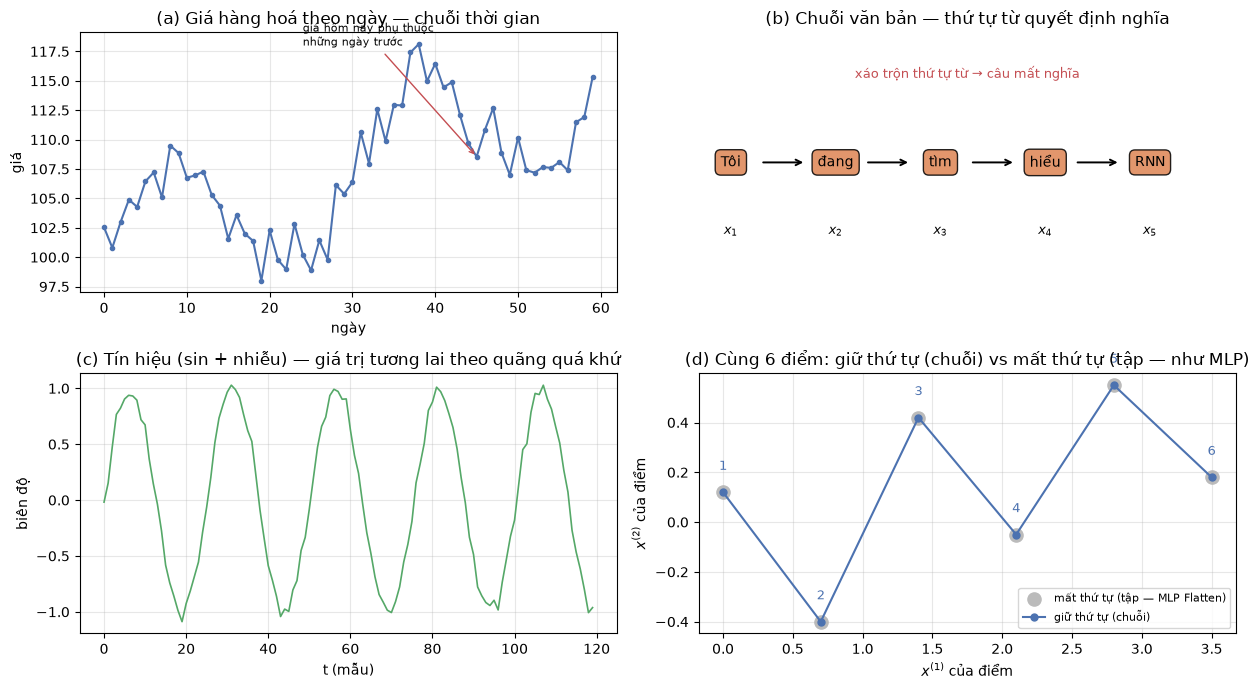

In [2]:
# ---- Minh hoạ 4 panel: giá hàng hoá / chuỗi văn bản / tín hiệu / chuỗi-vs-tập ----
rng1 = np.random.RandomState(7)
days = np.arange(60)
price = 100 + 0.25 * days + 6 * np.sin(2 * np.pi * days / 30) + rng1.normal(0, 1.5, 60)

fig, axes = plt.subplots(2, 2, figsize=(12.5, 7))

ax = axes[0, 0]                                   # (a) giá hàng hoá theo ngày
ax.plot(days, price, "-o", ms=3, color="#4C72B0")
ax.annotate("giá hôm nay phụ thuộc\nnhững ngày trước", xy=(45, price[45]), xytext=(24, 118),
            fontsize=8, arrowprops=dict(arrowstyle="->", color="#C44E52"))
ax.set_title("(a) Giá hàng hoá theo ngày — chuỗi thời gian")
ax.set_xlabel("ngày"); ax.set_ylabel("giá"); ax.grid(alpha=0.3)

ax = axes[0, 1]                                   # (b) chuỗi văn bản
ax.set_title("(b) Chuỗi văn bản — thứ tự từ quyết định nghĩa")
ax.set_xlim(0, 10); ax.set_ylim(0, 2); ax.axis("off")
words = ["Tôi", "đang", "tìm", "hiểu", "RNN"]
xs = np.linspace(0.6, 8.4, len(words))
for i, (w, x) in enumerate(zip(words, xs)):
    ax.text(x, 1, w, ha="center", va="center", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.4", fc="#DD8452", ec="black", alpha=0.85))
    ax.text(x, 0.45, "$x_{%d}$" % (i + 1), ha="center", fontsize=9)
    if i > 0:
        ax.annotate("", xy=(x - 0.55, 1), xytext=(xs[i - 1] + 0.55, 1),
                    arrowprops=dict(arrowstyle="->", lw=1.4))
ax.text(5, 1.65, "xáo trộn thứ tự từ → câu mất nghĩa", ha="center",
        fontsize=9, color="#C44E52")

ax = axes[1, 0]                                   # (c) tín hiệu sin + nhiễu
tt = np.arange(120)
sig = np.sin(0.25 * tt) + rng1.normal(0, 0.05, 120)
ax.plot(tt, sig, color="#55A868", lw=1.2)
ax.set_title("(c) Tín hiệu (sin + nhiễu) — giá trị tương lai theo quãng quá khứ")
ax.set_xlabel("t (mẫu)"); ax.set_ylabel("biên độ"); ax.grid(alpha=0.3)

ax = axes[1, 1]                                   # (d) chuỗi vs tập — MLP thấy gì?
ax.set_title("(d) Cùng 6 điểm: giữ thứ tự (chuỗi) vs mất thứ tự (tập — như MLP)")
pts = np.array([[0.0, 0.12], [0.7, -0.4], [1.4, 0.42], [2.1, -0.05],
                [2.8, 0.55], [3.5, 0.18]])
ax.scatter(pts[:, 0], pts[:, 1], s=90, color="#BBBBBB", label="mất thứ tự (tập — MLP Flatten)")
ax.plot(pts[:, 0], pts[:, 1], "-o", color="#4C72B0", ms=5, label="giữ thứ tự (chuỗi)")
for i, (px, py) in enumerate(pts):
    ax.annotate(str(i + 1), (px, py), xytext=(px, py + 0.09), ha="center",
                fontsize=9, color="#4C72B0")
ax.set_xlabel("$x^{(1)}$ của điểm"); ax.set_ylabel("$x^{(2)}$ của điểm")
ax.legend(fontsize=8, loc="lower right"); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "rnn-01-sequence-data.png", bbox_inches="tight")
plt.show()

 ---
 ## §2. Ý tưởng RNN + "unroll" — hidden state mang ký ức

 **Ý tưởng cốt lõi:** thay vì lưu toàn bộ quá khứ (dài vô hạn), RNN **nén** quá khứ vào một
 vector **trạng thái ẩn** $h_t \in \mathbb{R}^{d_h}$ và **cập nhật nó từng bước một**:

 1. đọc đầu vào hiện tại $x_t$;
 2. kết hợp với ký ức bước trước $h_{t-1}$ → ra ký ức mới $h_t$;
 3. từ $h_t$ sinh đầu ra $y_t$.

 Vì cập nhật lặp đi lặp lại **cùng một hàm**, ta có thể vẽ network theo 2 cách:

 - **Cuộn (rolled):** một block RNN với mũi tên **tự vòng lại chính nó** (ký ức $h$ đi một vòng).
 - **Trải (unrolled):** mở vòng đó ra theo trục thời gian — mỗi bước là **một bản sao** của
   cùng block; $h_0 = 0$ (khởi tạo), sau T bước ta có $h_1, h_2, \dots, h_T$.

 Điểm mấu chốt: **trải ra chỉ để dễ hiểu/tính đạo hàm** — vẫn là MỘT mô hình với MỘT bộ trọng số.

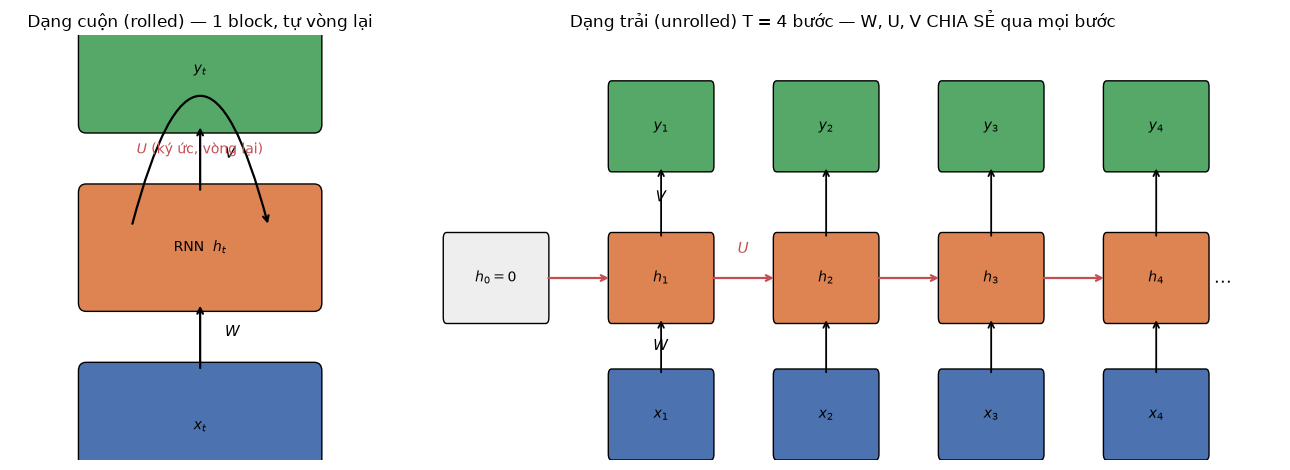

In [3]:
# ---- Sơ đồ RNN cuộn (trái) và trải T=4 bước (phải) ----
from matplotlib.patches import FancyBboxPatch

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={"width_ratios": [1, 2.3]})

def _box(ax, x, y, text, fc):
    """Vẽ 1 hộp bo góc tại (x, y) — chỉ dùng cho sơ đồ này."""
    ax.add_patch(FancyBboxPatch((x - 0.30, y - 0.13), 0.60, 0.26,
                                boxstyle="round,pad=0.02", fc=fc, ec="black", lw=1.0))
    ax.text(x, y, text, ha="center", va="center", fontsize=10)

# (trái) dạng cuộn — block tự vòng lại
ax1.set_title("Dạng cuộn (rolled) — 1 block, tự vòng lại")
ax1.set_xlim(0, 1); ax1.set_ylim(0, 1); ax1.axis("off")
_box(ax1, 0.5, 0.50, "RNN  $h_t$", "#DD8452")
_box(ax1, 0.5, 0.08, "$x_t$", "#4C72B0")
_box(ax1, 0.5, 0.92, "$y_t$", "#55A868")
ax1.annotate("", xy=(0.5, 0.37), xytext=(0.5, 0.21), arrowprops=dict(arrowstyle="->", lw=1.6))
ax1.text(0.565, 0.29, "$W$", fontsize=11)
ax1.annotate("", xy=(0.5, 0.79), xytext=(0.5, 0.63), arrowprops=dict(arrowstyle="->", lw=1.6))
ax1.text(0.565, 0.71, "$V$", fontsize=11)
ax1.annotate("", xy=(0.68, 0.55), xytext=(0.32, 0.55),
             arrowprops=dict(arrowstyle="->", lw=1.6, connectionstyle="arc3,rad=-1.9"))
ax1.text(0.50, 0.30 + 0.42, "$U$ (ký ức, vòng lại)", fontsize=10, ha="center", color="#C44E52")

# (phải) dạng trải — T = 4 bước, trọng số chia sẻ
ax2.set_title("Dạng trải (unrolled) T = 4 bước — W, U, V CHIA SẺ qua mọi bước")
ax2.set_xlim(-0.55, 4.75); ax2.set_ylim(-0.05, 1.35); ax2.axis("off")
_box(ax2, 0.0, 0.55, "$h_0{=}0$", "#EEEEEE")
for t in range(1, 5):
    _box(ax2, t, 0.10, "$x_{%d}$" % t, "#4C72B0")
    _box(ax2, t, 0.55, "$h_{%d}$" % t, "#DD8452")
    _box(ax2, t, 1.05, "$y_{%d}$" % t, "#55A868")
    ax2.annotate("", xy=(t, 0.42), xytext=(t, 0.23), arrowprops=dict(arrowstyle="->", lw=1.3))
    ax2.annotate("", xy=(t, 0.92), xytext=(t, 0.68), arrowprops=dict(arrowstyle="->", lw=1.3))
    ax2.annotate("", xy=(t - 0.30, 0.55), xytext=(t - 1 + 0.30, 0.55),
                 arrowprops=dict(arrowstyle="->", lw=1.6, color="#C44E52"))
ax2.text(1.0, 0.31, "$W$", fontsize=11, ha="center")
ax2.text(1.5, 0.63, "$U$", fontsize=11, ha="center", color="#C44E52")
ax2.text(1.0, 0.80, "$V$", fontsize=11, ha="center")
ax2.text(4.35, 0.55, "...", fontsize=13, va="center")

plt.tight_layout()
plt.savefig(FIG_DIR / "rnn-02-unrolled.png", bbox_inches="tight")
plt.show()

 ---
 ## §3. Ký hiệu, công thức và KÍCH THUỚC ma trận

 **Công thức chuẩn (quy ước ASM06):**

 $$h_t = \tanh(W x_t + U h_{t-1} + b_h) \qquad y_t = V h_t + b_y, \qquad h_0 = 0$$

 | Ký hiệu | Ý nghĩa | Kích thước | Vai trò |
 |---|---|---|---|
 | $x_t$ | đầu vào bước $t$ | $(d_x,)$ | một phần tử chuỗi (giá ngày, vector từ...) |
 | $h_t$ | trạng thái ẩn bước $t$ | $(d_h,)$ | **bộ nhớ** nén toàn bộ quá khứ $x_1..x_t$ |
 | $h_0$ | trạng thái khởi tạo | $(d_h,)$ | quy ước = vector 0 |
 | $W$ | input → hidden | $(d_h \times d_x)$ | chiếu $x_t$ vào không gian ẩn |
 | $U$ | hidden → hidden | $(d_h \times d_h)$ | **TRỌNG TÂM: truyền ký ức** $h_{t-1} \to h_t$ |
 | $V$ | hidden → output | $(d_y \times d_h)$ | đọc $h_t$ ra dự đoán $y_t$ |
 | $b_h,\ b_y$ | bias | $(d_h,), (d_y,)$ | dịch chuyển |

 **Trọng số CHIA SẺ:** chỉ có MỘT bộ $(W, U, V, b_h, b_y)$ dùng lại ở **mọi** thời điểm
 $t = 1..T$ (đúng như sơ đồ §2 trải ra nhưng màu trọng số lặp lại). Hệ quả:

 $$\text{số tham số} = d_h d_x + d_h d_h + d_y d_h + d_h + d_y \quad \text{— KHÔNG phụ thuộc } T$$

 Nếu mỗi bước dùng bộ trọng số riêng (kiểu MLP), chuỗi dài $T$ cần gấp $T$ lần tham số —
 đây chính là lợi thế "cửa tuýp" (parameter sharing) của RNN.

In [4]:
def n_params(dx, dh, dy):
    """Số tham số RNN: d_h*d_x + d_h*d_h + d_y*d_h + d_h + d_y (không phụ thuộc T)."""
    return dh * dx + dh * dh + dy * dh + dh + dy

rows = []
for T in [4, 10, 100, 1000]:
    rows.append({"độ dài chuỗi T": T, "số tham số RNN": n_params(2, 3, 1)})
df_share = pd.DataFrame(rows)
print(df_share.to_string(index=False))
print("=> tham số KHÔNG đổi khi chuỗi dài ra (W,U,V dùng lại).")
print("Riêng bộ (d_x=2, d_h=3, d_y=1):",
      dict(W=6, U=9, V=3, b_h=3, b_y=1), "tổng =", n_params(2, 3, 1))

 độ dài chuỗi T  số tham số RNN
              4              22
             10              22
            100              22
           1000              22
=> tham số KHÔNG đổi khi chuỗi dài ra (W,U,V dùng lại).
Riêng bộ (d_x=2, d_h=3, d_y=1): {'W': 6, 'U': 9, 'V': 3, 'b_h': 3, 'b_y': 1} tổng = 22


 ---
 ## §4. Cài đặt RNN bằng numpy thuần — từng bước

 Tách thành 2 hàm nhỏ đúng như công thức:

 - `rnn_cell` = **một bước** cập nhật ký ức (công thức $h_t$);
 - `rnn_forward` = **cả chuỗi**: lặp `rnn_cell` theo $t = 1..T$ rồi tính $y_t$.

 **Hàm `rnn_cell(x_t, h_prev, W, U, b_h)`** — công thức:

 $$a_t = W x_t + U h_{t-1} + b_h, \qquad h_t = \tanh(a_t)$$

 - **Vai trò:** đọc đầu vào mới + ký ức cũ → ký ức mới (đây là "neuron hồi tiếp").
 - **Input:** `x_t` $(d_x,)$, `h_prev` $(d_h,)$, `W` $(d_h, d_x)$, `U` $(d_h, d_h)$, `b_h` $(d_h,)$.
 - **Output:** `h_t` $(d_h,)$ — vector ký ức mới.

In [5]:
def rnn_cell(x_t, h_prev, W, U, b_h):
    """Một bước RNN: h_t = tanh(W x_t + U h_(t-1) + b_h)."""
    a_t = W @ x_t + U @ h_prev + b_h     # pre-activation (d_h,)
    return np.tanh(a_t)


# demo nhanh: 1 bước với số nhỏ
_x = np.array([1.0, 0.5]); _h = np.zeros(3)
_Wd = np.array([[0.5, -0.2], [0.3, 0.8], [-0.6, 0.1]])
_Ud = np.array([[0.2, 0.0, -0.1], [0.1, 0.3, 0.0], [0.0, -0.2, 0.4]])
_bd = np.array([0.1, -0.1, 0.0])
print("h_1 = tanh(W x_1 + U h_0 + b_h) =", np.round(rnn_cell(_x, _h, _Wd, _Ud, _bd), 4))

h_1 = tanh(W x_1 + U h_0 + b_h) = [ 0.4621  0.537  -0.5005]


 **Hàm `rnn_forward(X, W, U, b_h, V, b_y)`** — công thức cho $t = 1..T$:

 $$h_t = \tanh(W x_t + U h_{t-1} + b_h) \;\; (\text{khởi tạo } h_0 = 0), \qquad y_t = V h_t + b_y$$

 - **Vai trò:** chạy nguyên chuỗi, trả về **toàn bộ** trạng thái ẩn $h_0..h_T$ (giữ $h_0$
   để phục vụ BPTT ở §7) và toàn bộ đầu ra $y_1..y_T$.
 - **Input:** `X` $(T, d_x)$ — mỗi HÀNG là một bước $x_t$; các ma trận như §3.
 - **Output:** tuple `(H, Y)` với `H` $(T{+}1, d_h)$ — gồm cả $h_0 = 0$, và `Y` $(T, d_y)$.

In [6]:
def rnn_forward(X, W, U, b_h, V, b_y):
    """Chạy chuỗi T bước, trả (H (T+1, d_h) gồm h_0=0, Y (T, d_y))."""
    T, dx = X.shape
    dh = W.shape[0]
    H = np.zeros((T + 1, dh))            # H[0] = h_0 = 0
    Y = np.zeros((T, V.shape[0]))
    for t in range(T):
        H[t + 1] = rnn_cell(X[t], H[t], W, U, b_h)   # h_{t+1} (0-based)
        Y[t] = V @ H[t + 1] + b_y                    # y_{t+1}
    return H, Y


rng4 = np.random.RandomState(RANDOM_SEED)            # bộ trọng số demo §4 → dùng lại §9, §10
D_X, D_H, D_Y, T_DEMO = 2, 3, 1, 4
W = rng4.randn(D_H, D_X) * 0.8
U = rng4.randn(D_H, D_H) * 0.8
b_h = rng4.randn(D_H) * 0.3
V = rng4.randn(D_Y, D_H) * 0.8
b_y = rng4.randn(D_Y) * 0.3
X_demo = rng4.randn(T_DEMO, D_X)

print("W (d_h x d_x) =", W.shape); print(np.round(W, 3))
print("U (d_h x d_h) =", U.shape); print(np.round(U, 3))
print("V (d_y x d_h) =", V.shape); print(np.round(V, 3))

H_demo, Y_demo = rnn_forward(X_demo, W, U, b_h, V, b_y)
print("\nh_0 shape", H_demo[0].shape, "=", H_demo[0])
for t in range(1, T_DEMO + 1):
    print("h_%d shape %s = %s" % (t, H_demo[t].shape, np.round(H_demo[t], 4)))
for t in range(1, T_DEMO + 1):
    print("y_%d shape %s = %s" % (t, Y_demo[t - 1].shape, np.round(Y_demo[t - 1], 4)))

W (d_h x d_x) = (3, 2)
[[ 0.397 -0.111]
 [ 0.518  1.218]
 [-0.187 -0.187]]
U (d_h x d_h) = (3, 3)
[[ 1.263  0.614 -0.376]
 [ 0.434 -0.371 -0.373]
 [ 0.194 -1.531 -1.38 ]]
V (d_y x d_h) = (1, 3)
[[-0.726 -1.13   1.173]]

h_0 shape (3,) = [0. 0. 0.]
h_1 shape (3,) = [ 0.0157 -0.9644  0.335 ]
h_2 shape (3,) = [-0.7988 -0.2082  0.8313]
h_3 shape (3,) = [-0.9714 -0.7706 -0.6313]
h_4 shape (3,) = [-0.9506 -0.702   0.9718]
y_1 shape (1,) = [1.4033]
y_2 shape (1,) = [1.7224]
y_3 shape (1,) = [0.7683]
y_4 shape (1,) = [2.5554]


 ---
 ## §5. Ví dụ số — tính TAY từng bước

 Làm tròn trọng số §4 còn 2 chữ số thập phân và chọn đầu vào "đẹp" để đọc được:
 $x_1 = [1.0,\, 0.5]$, $x_2 = [0.8,\, -0.3]$, $x_3 = [-0.2,\, 0.9]$, $x_4 = [0.4,\, 0.4]$.
 Mỗi bước tính đúng theo: $a_t = \underbrace{W x_t}_{\text{đầu vào mới}} +
 \underbrace{U h_{t-1}}_{\text{ký ức cũ}} + b_h$, rồi $h_t = \tanh(a_t)$.

 **Hàm `fmt_vec(v, nd)`** — công thức: không có (tiện ích hiển thị).
 - **Vai trò:** định dạng vector numpy thành chuỗi `[0.12 -0.34 ...]` để in vào bảng.
 - **Input:** vector `v`, số chữ số lẻ `nd`. **Output:** chuỗi.

In [7]:
def fmt_vec(v, nd=2):
    """Định dạng vector thành chuỗi [a b c] để đọc trong bảng."""
    return "[" + " ".join("%.*f" % (nd, x) for x in v) + "]"


W2, U2, bh2 = np.round(W, 2), np.round(U, 2), np.round(b_h, 2)
V2, by2 = np.round(V, 2), np.round(b_y, 2)
X_read = np.array([[1.0, 0.5], [0.8, -0.3], [-0.2, 0.9], [0.4, 0.4]])

rows, h_prev = [], np.zeros(D_H)
for t in range(4):
    x_t = X_read[t]
    wx = W2 @ x_t                 # phần đầu vào mới
    uh = U2 @ h_prev              # phần ký ức cũ
    a_t = wx + uh + bh2           # tổng
    h_t = np.tanh(a_t)
    y_t = V2 @ h_t + by2
    rows.append({"t": t + 1, "x_t": fmt_vec(x_t), "h_(t-1)": fmt_vec(h_prev),
                 "W·x_t": fmt_vec(wx), "U·h_(t-1)": fmt_vec(uh), "b_h": fmt_vec(bh2),
                 "a_t (tổng)": fmt_vec(a_t), "h_t = tanh(a_t)": fmt_vec(h_t),
                 "y_t": "%.3f" % y_t[0]})
    h_prev = h_t

df_hand = pd.DataFrame(rows)
df_hand

,t,x_t,h_(t-1),W·x_t,U·h_(t-1),b_h,a_t (tổng),h_t = tanh(a_t),y_t
0,1,[1.00 0.50],[0.00 0.00 0.00],[0.35 1.13 -0.29],[0.00 0.00 0.00],[-0.17 -0.30 0.09],[0.18 0.83 -0.20],[0.17 0.68 -0.19],-1.191
1,2,[0.80 -0.30],[0.17 0.68 -0.19],[0.35 0.05 -0.10],[0.71 -0.11 -0.74],[-0.17 -0.30 0.09],[0.89 -0.36 -0.75],[0.71 -0.34 -0.63],-0.944
2,3,[-0.20 0.90],[0.71 -0.34 -0.63],[-0.18 0.99 -0.13],[0.93 0.67 1.53],[-0.17 -0.30 0.09],[0.58 1.36 1.49],[0.52 0.88 0.90],-0.385
3,4,[0.40 0.40],[0.52 0.88 0.90],[0.12 0.70 -0.15],[0.85 -0.43 -2.49],[-0.17 -0.30 0.09],[0.80 -0.04 -2.55],[0.66 -0.04 -0.99],-1.666


 **Đọc bảng trên:** cột `W·x_t` chỉ phụ thuộc đầu vào hiện tại; cột `U·h_(t-1)` là
 **dòng ký ức** — bước $t{=}1$ nó bằng 0 (vì $h_0=0$), các bước sau mang vết của mọi
 $x_1..x_{t-1}$. Đó là lý do $U$ được gọi là ma trận **ký ức**.

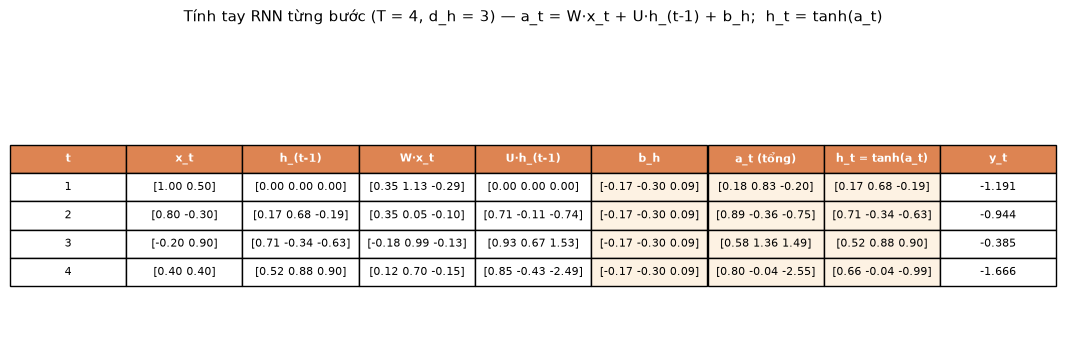

In [8]:
fig, ax = plt.subplots(figsize=(13.5, 3.6))
ax.axis("off")
tbl = ax.table(cellText=df_hand.values, colLabels=df_hand.columns,
               cellLoc="center", loc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1, 1.7)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#DD8452"); cell.set_text_props(weight="bold", color="white")
    elif c in (5, 6, 7):
        cell.set_facecolor("#FDF2E3")     # tô nhẹ các cột tính trung gian
ax.set_title("Tính tay RNN từng bước (T = 4, d_h = 3) — a_t = W·x_t + U·h_(t-1) + b_h;  h_t = tanh(a_t)",
             fontsize=11, pad=40)
plt.savefig(FIG_DIR / "rnn-03-worked-example.png", bbox_inches="tight")
plt.show()

 ---
 ## §6. Hàm mất mát trên chuỗi

 Với cặp chuỗi dự đoán $\{y_t\}$ và nhãn $\{\text{target}_t\}$ ($t = 1..T$), dùng MSE
 **trung bình trên chuỗi**:

 $$L = \frac{1}{T}\sum_{t=1}^{T} (y_t - \text{target}_t)^2, \qquad
 \frac{\partial L}{\partial y_t} = \frac{2}{T}(y_t - \text{target}_t)$$

 **Hàm `loss_seq(Y, targets)`** — công thức: $L$ ở trên.
 - **Vai trò:** đo độ lệch dự đoán trên cả chuỗi (mỗi bước đều được giám sát).
 - **Input:** `Y` $(T, d_y)$, `targets` $(T, d_y)$. **Output:** số thực $L$.

In [9]:
def loss_seq(Y, targets):
    """MSE trung bình trên chuỗi: L = mean_t ||y_t - target_t||^2."""
    diff = Y - targets
    return float(np.mean(diff * diff))

 **Hàm `dloss_seq(Y, targets)`** — công thức: $\partial L/\partial y_t = \frac{2}{T}(y_t - \text{target}_t)$.
 - **Vai trò:** đạo hàm cấp 1 của mất mát theo đầu ra từng bước — điểm khởi đầu của BPTT (§7).
 - **Input:** `Y`, `targets` $(T, d_y)$. **Output:** `dY` $(T, d_y)$.

In [10]:
def dloss_seq(Y, targets):
    """Đạo hàm L theo y_t: dY = 2/T * (Y - targets)."""
    T = Y.shape[0]
    return (2.0 / T) * (Y - targets)


targets_demo = X_demo.sum(axis=1, keepdims=True) * 0.3      # nhãn giả định để demo
L_demo = loss_seq(Y_demo, targets_demo)
print("L =", round(L_demo, 6), "| dY[0] =", np.round(dloss_seq(Y_demo, targets_demo)[0], 4))

L = 3.920286 | dY[0] = [0.9052]


 ---
 ## §7. BPTT — Backpropagation Through Time

 BPTT = đạo hàm chuỗi trên **mạng đã trải** (§2 phải): lỗi ở bước $t$ phải truyền ngược
 **qua mọi bước trước đó**. Dẫn đạo hàm từng bước:

 **Bước 1 — đầu ra (trực tiếp):**
 $$\frac{\partial L}{\partial V} = \sum_{t=1}^{T} \delta^y_t h_t^\top, \qquad
 \frac{\partial L}{\partial b_y} = \sum_{t=1}^{T} \delta^y_t, \qquad
 \delta^y_t \equiv \frac{\partial L}{\partial y_t} = \frac{2}{T}(y_t - \text{target}_t)$$

 **Bước 2 — vào hidden state (đường cong hồi):**
 $$\frac{\partial L}{\partial h_t} = V^\top \delta^y_t + U^\top \underbrace{\mathrm{diag}(1 - \tanh^2 a_{t+1})\, \frac{\partial L}{\partial h_{t+1}}}_{\text{đi ngược 1 bước thời gian}}$$

 **Bước 3 — vào trọng số (cộng dồn qua thời gian vì trọng số chia sẻ):**
 $$\frac{\partial L}{\partial W} = \sum_{t=1}^{T} \delta_t x_t^\top, \qquad
 \frac{\partial L}{\partial U} = \sum_{t=1}^{T} \delta_t h_{t-1}^\top, \qquad
 \delta_t \equiv \frac{\partial L}{\partial a_t} = (1 - h_t^2) \odot \frac{\partial L}{\partial h_t}$$

 (dùng $\tanh'(a_t) = 1 - \tanh^2(a_t) = 1 - h_t^2$).

 **Hàm `rnn_backward(X, H, Y, targets, W, U, V)`** — công thức: 3 bước trên.
 - **Vai trò:** tính gradient $\partial L/\partial(W, U, V, b_h, b_y)$ cho MỘT chuỗi.
 - **Input:** `X` $(T, d_x)$; `H` $(T{+}1, d_h)$ và `Y` $(T, d_y)$ từ `rnn_forward`; `targets` $(T, d_y)$.
 - **Output:** dict `{"W","U","V","b_h","b_y"}` gradient cùng shape tham số.

In [11]:
def rnn_backward(X, H, Y, targets, W, U, V):
    """BPTT cho 1 chuỗi: trả dict gradient cho W, U, V, b_h, b_y."""
    T = X.shape[0]
    dY = dloss_seq(Y, targets)                       # (T, d_y) — đạo hàm tại đầu ra
    gW = np.zeros_like(W); gU = np.zeros_like(U); gV = np.zeros_like(V)
    gbh = np.zeros(W.shape[0], dtype=W.dtype); gby = np.zeros(Y.shape[1], dtype=Y.dtype)
    gV += dY.T @ H[1:]                               # sum_t dy_t h_t^T
    gby += dY.sum(axis=0)
    dh = dY[T - 1] @ V                               # dL/dh_T
    for k in range(T, 0, -1):                        # h_k ← a_{k-1} ← (x_{k-1}, h_{k-1})
        da = dh * (1.0 - H[k] ** 2)                  # dL/da_{k-1} = (1-h_k^2) * dL/dh_k
        gW += np.outer(da, X[k - 1])                 # sum_t delta_t x_t^T
        gU += np.outer(da, H[k - 1])                 # sum_t delta_t h_(t-1)^T
        gbh += da
        if k > 1:
            dh = U.T @ da + dY[k - 2] @ V            # dL/dh_(k-1) = U^T·δ_k + V^T·δ^y_(k-1)
    return {"W": gW, "U": gU, "V": gV, "b_h": gbh, "b_y": gby}


grads_demo = rnn_backward(X_demo, H_demo, Y_demo, targets_demo, W, U, V)
print({k: np.round(v, 4).tolist() for k, v in grads_demo.items()})

{'W': [[0.1412, 2.3738], [1.6063, 0.0607], [-0.6003, -1.8037]], 'U': [[0.1288, 0.3373, -0.0635], [0.9111, 2.2677, -0.2045], [-0.4704, -0.3232, 0.394]], 'V': [[-2.5537, -2.4423, 2.1291]], 'b_h': [-2.0843, -2.7193, 2.1162], 'b_y': [3.7435]}


 ### Gradient check bằng sai phân (finite differences)

 **Kiểm định:** xấp xỉ số học $\frac{\partial L}{\partial \theta} \approx
 \frac{L(\theta + \varepsilon) - L(\theta - \varepsilon)}{2\varepsilon}$ với
 $\varepsilon = 10^{-6}$, so với gradient giải tích từ `rnn_backward`.

 **Hàm `numeric_grad(fun, params, eps)`** — công thức: sai phân trung tâm ở trên.
 - **Vai trò:** tính gradient "bằng định nghĩa" cho MỘT tham số — chuẩn vàng để test code BPTT.
 - **Input:** hàm vô hướng `fun(params)`, dict `params`, bước `eps`.
 - **Output:** dict gradient số học cùng shape.

In [12]:
def numeric_grad(fun, params, eps=1e-6):
    """Gradient sai phân trung tâm cho từng phần tử của dict params."""
    out = {}
    for key, val in params.items():
        g = np.zeros_like(val)
        it = np.nditer(val, flags=["multi_index"])
        while not it.finished:
            idx = it.multi_index
            old = val[idx]
            val[idx] = old + eps; lp = fun(params)
            val[idx] = old - eps; lm = fun(params)
            val[idx] = old
            g[idx] = (lp - lm) / (2 * eps)
            it.iternext()
        out[key] = g
    return out


params_demo = {"W": W, "U": U, "V": V, "b_h": b_h, "b_y": b_y}

def _loss_of(p):
    """L(params) gói rnn_forward + loss_seq để sai phân gọi."""
    _, Yc = rnn_forward(X_demo, p["W"], p["U"], p["b_h"], p["V"], p["b_y"])
    return loss_seq(Yc, targets_demo)

num_demo = numeric_grad(_loss_of, params_demo)
rows = []
for key in params_demo:
    a, n = grads_demo[key].ravel(), num_demo[key].ravel()
    rel = np.abs(a - n) / np.maximum(1e-8, np.abs(a) + np.abs(n))
    rows.append({"tham số": key, "n phần tử": a.size,
                 "max rel err": "%.3e" % rel.max()})
df_check = pd.DataFrame(rows)
max_rel = max(float(r["max rel err"]) for r in rows)
print(df_check.to_string(index=False))
print("MAX SAI SỐ TƯƠNG ĐỐI = %.3e  (yêu cầu < 1e-6)" % max_rel)
assert max_rel < 1e-6, "Gradient check FAIL — BPTT sai!"
print("=> PASS: BPTT numpy đúng với gradient sai phân.")

tham số  n phần tử max rel err
      W          6   7.729e-10
      U          9   4.023e-09
      V          3   1.577e-10
    b_h          3   4.207e-11
    b_y          1   2.525e-11
MAX SAI SỐ TƯƠNG ĐỐI = 4.023e-09  (yêu cầu < 1e-6)
=> PASS: BPTT numpy đúng với gradient sai phân.


 ---
 ## §8. Gradient biến mất (vanishing) và bùng nổ (exploding)

 Từ §7: đi ngược 1 bước thời gian, gradient nhân thêm Jacobian

 $$J = U^\top\,\mathrm{diag}(1 - \tanh^2 a) \quad\Rightarrow\quad
 \|J\| \le \|U^\top\|\cdot\max(1 - \tanh^2) \le \|U\|$$

 Đi ngược $k$ bước → nhân $k$ lần: $\|\partial L/\partial h_t\| \sim \|U\|^{\,T-t}$.

 - $\|U\| < 1$ → gradient **biến mất theo hàm mũ** (mô hình không học được phụ thuộc xa);
 - $\|U\| > 1$ → gradient **bùng nổ** (làm huấn luyện lung lay, thậm chí NaN).

 **Hàm `dh_norms_last_only(X, W, U, b_h, V, target)`** — công thức: đệ quy
 $\partial L/\partial h_t = U^\top\,\mathrm{diag}(1-h_{t+1}^2)\,\partial L/\partial h_{t+1}$,
 khởi tạo $\partial L/\partial h_T = V^\top\,\delta^y_T$ (loss CHỈ đặt ở bước cuối).
 - **Vai trò:** đo chuẩn gradient hidden state theo $t$ — đo trực tiếp sự biến mất/bùng nổ.
 - **Input:** chuỗi `X` $(T, d_x)$, trọng số, nhãn cuối `target`. **Output:** mảng $(T{+}1,)$ — $\|\partial L/\partial h_t\|$.

In [13]:
def dh_norms_last_only(X, W, U, b_h, V, target):
    """Chuẩn ||dL/dh_t|| khi loss chỉ ở bước cuối T (đi ngược chỉ qua Jacobian U)."""
    T = X.shape[0]
    H, Y = rnn_forward(X, W, U, b_h, V, b_y=np.zeros(V.shape[0]))
    norms = np.zeros(T + 1)
    dh = (2.0 * (Y[T - 1, 0] - target)) * V[0]       # dL/dh_T (d_y = 1)
    norms[T] = np.linalg.norm(dh)
    for k in range(T, 0, -1):                        # h_k → h_(k-1)
        da = dh * (1.0 - H[k] ** 2)
        dh = U.T @ da                                # dL/dh_(k-1) = U^T diag(1-h_k^2) dL/dh_k
        norms[k - 1] = np.linalg.norm(dh)
    return norms


rng8 = np.random.RandomState(RANDOM_SEED)
D_H8, T8 = 16, 30
X8 = rng8.randn(T8, 1) * 0.5
q8, _ = np.linalg.qr(rng8.randn(D_H8, D_H8))         # ma trận trực giao → ||U|| = scale
W8 = 0.5 * rng8.randn(D_H8, 1)                       # input nhỏ → h chưa bão hoà tanh
V8 = rng8.randn(1, D_H8) / np.sqrt(D_H8)
bh8 = np.zeros(D_H8)

norms_small = dh_norms_last_only(X8, W8, 0.5 * q8, bh8, V8, target=0.5)
norms_big = dh_norms_last_only(X8, W8, 2.5 * q8, bh8, V8, target=0.5)
print("||U||=0.5 : ||dL/dh_T||=%.3e → ||dL/dh_0||=%.3e  (biến mất)"
      % (norms_small[-1], norms_small[0]))
print("||U||=2.5 : ||dL/dh_T||=%.3e → ||dL/dh_1||=%.3e  (bùng nổ)"
      % (norms_big[-1], np.nanmax(norms_big)))

||U||=0.5 : ||dL/dh_T||=6.685e-01 → ||dL/dh_0||=3.590e-10  (biến mất)
||U||=2.5 : ||dL/dh_T||=4.319e-01 → ||dL/dh_1||=3.704e+03  (bùng nổ)


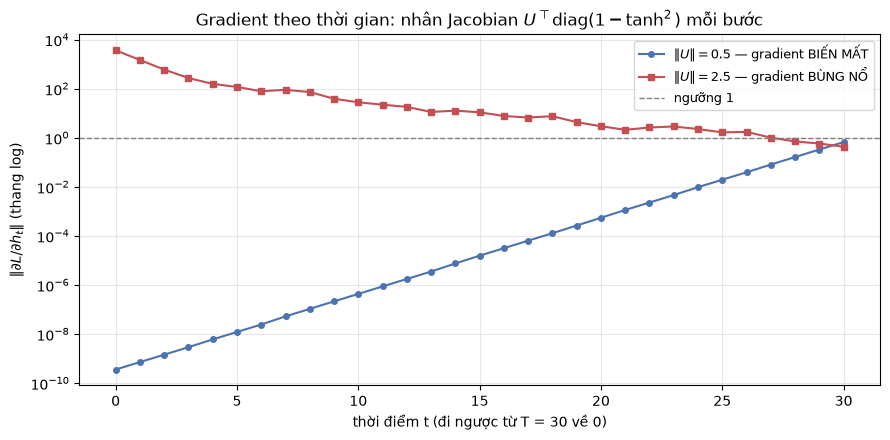

In [14]:
plt.figure(figsize=(9, 4.5))
plt.semilogy(np.arange(T8 + 1), norms_small + 1e-300, "o-", ms=4,
             color="#4C72B0", label=r"$\|U\| = 0.5$ — gradient BIẾN MẤT")
plt.semilogy(np.arange(T8 + 1), norms_big + 1e-300, "s-", ms=4,
             color="#C44E52", label=r"$\|U\| = 2.5$ — gradient BÙNG NỔ")
plt.axhline(1.0, color="gray", ls="--", lw=1, label="ngưỡng 1")
plt.xlabel("thời điểm t (đi ngược từ T = %d về 0)" % T8)
plt.ylabel(r"$\|\partial L/\partial h_t\|$ (thang log)")
plt.title("Gradient theo thời gian: nhân Jacobian $U^\\top\\mathrm{diag}(1-\\tanh^2)$ mỗi bước")
plt.legend(fontsize=9); plt.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig(FIG_DIR / "rnn-04-vanishing.png", bbox_inches="tight")
plt.show()

 ### Cách chữa + tiến hoá sang LSTM/GRU

 **1) Gradient clipping (chữa bùng nổ):** cắt chuẩn gradient về ngưỡng $c$:
 $$g \leftarrow g \cdot \min\left(1, \frac{c}{\|g\|}\right)$$

 **Hàm `clip_grad_norm(grads, max_norm)`** — công thức như trên.
 - **Vai trò:** giữ hướng gradient nhưng giới hạn độ lớn — kỹ thuật LUÔN dùng khi huấn luyện RNN.
 - **Input:** dict gradient, ngưỡng `max_norm`. **Output:** dict gradient đã cắt + hệ số scale.

In [15]:
def clip_grad_norm(grads, max_norm=5.0):
    """Cắt chuẩn L2 của toàn bộ gradient về max_norm (giữ hướng)."""
    total = np.sqrt(sum(float(np.sum(g * g)) for g in grads.values()))
    scale = min(1.0, max_norm / (total + 1e-12))
    return {k: v * scale for k, v in grads.items()}, scale


peak8 = norms_big[1:].max()                          # gradient bùng nổ nhất (đi ngược gần h_0)
g_explode = {"U": peak8 * (2.5 * q8)[0] / D_H8}      # vector mô phỏng grad bùng nổ
g_clip, sc = clip_grad_norm(g_explode, max_norm=5.0)
print("trước cắt: ||g|| = %.3e → sau cắt: ||g|| = %.3f (scale = %.2e)"
      % (np.linalg.norm(g_explode["U"]), np.linalg.norm(g_clip["U"]), sc))

trước cắt: ||g|| = 2.326e+02 → sau cắt: ||g|| = 5.000 (scale = 2.15e-02)


 **2) LSTM (1997) — thêm "đường băng ô nhớ" $c_t$ chảy gần như nguyên vẹn**, gradient đi qua
 phép **cộng** và cổng quên thay vì chỉ qua nhân ma trận:

 $$i_t = \sigma(W_i x_t + U_i h_{t-1} + b_i), \quad f_t = \sigma(W_f x_t + U_f h_{t-1} + b_f),$$
 $$o_t = \sigma(W_o x_t + U_o h_{t-1} + b_o), \quad \tilde{c}_t = \tanh(W_c x_t + U_c h_{t-1} + b_c),$$
 $$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t, \qquad h_t = o_t \odot \tanh(c_t)$$

 **3) GRU (2014) — rút gọn LSTM còn 2 cổng** $(z, r)$, gộp hidden và cell state:

 $$z_t = \sigma(W_z x_t + U_z h_{t-1} + b_z), \qquad r_t = \sigma(W_r x_t + U_r h_{t-1} + b_r),$$
 $$\tilde{h}_t = \tanh(W_h x_t + U_h (r_t \odot h_{t-1}) + b_h), \qquad
 h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$$

 | Tiêu chí | RNN cơ bản | LSTM | GRU |
 |---|---|---|---|
 | Tham số (tương đối) | $1\times$ | $\approx 4\times$ | $\approx 3\times$ |
 | Phụ thuộc dài hạn | yếu (gradient biến mất) | tốt (đường $c_t$ + cổng quên) | tốt |
 | Tốc độ train | nhanh nhất | chậm nhất | trung gian |
 | Khi nào dùng | chuỗi ngắn, ít dữ liệu, làm nền tảng hiểu | chuỗi dài, cần nhớ xa, dữ liệu nhiều | chuỗi dài, muốn nhanh/ít tham số hơn LSTM |

 > Các notebook sau của ASM06 sẽ dùng `nn.LSTM`/`keras.layers.LSTM` trên dữ liệu giá thật —
 > notebook này chỉ tập trung cơ chế RNN nguyên thuỷ.

 ---
 ## §9. Đối chiếu PyTorch `nn.RNN`

 `nn.RNN(input_size=2, hidden_size=3, batch_first=True)` tính **đúng** công thức §3.
 PyTorch tách bias thành 2 phần nên mapping là:

 $$\underbrace{W}_{\texttt{weight\_ih\_l0}}\;(d_h \times d_x), \qquad
 \underbrace{U}_{\texttt{weight\_hh\_l0}}\;(d_h \times d_h), \qquad
 \underbrace{b_h}_{\texttt{bias\_ih\_l0} + \texttt{bias\_hh\_l0}}$$

 Thử nghiệm kiểm định: **copy** bộ $W, U, b_h$ của §4 (numpy) vào trọng số PyTorch
 (`no_grad` + `copy_`, đặt `bias_hh_l0 = 0`), chạy cùng input `X_demo` — nếu kết quả
 trùng numpy tới ~$10^{-7}$ thì mapping W/U/V và công thức đã đúng.

In [16]:
import torch
import torch.nn as nn

torch.set_num_threads(4)
torch.manual_seed(RANDOM_SEED)

rnn_pt = nn.RNN(input_size=D_X, hidden_size=D_H, batch_first=True).double()
with torch.no_grad():                                  # copy trọng số numpy → PyTorch
    rnn_pt.weight_ih_l0.copy_(torch.from_numpy(W))     # = W  (d_h, d_x)
    rnn_pt.weight_hh_l0.copy_(torch.from_numpy(U))     # = U  (d_h, d_h)
    rnn_pt.bias_ih_l0.copy_(torch.from_numpy(b_h))     # b_h chia 2 phần:
    rnn_pt.bias_hh_l0.zero_()                          # bias_ih + bias_hh = b_h + 0
out_pt, h_n_pt = rnn_pt(torch.from_numpy(X_demo)[None])    # (1, T, d_h), (1, 1, d_h)
H_pt = out_pt[0].detach().numpy()                      # h_1..h_T
Y_pt = H_pt @ V.T + b_y                                # tự nhân V như công thức

diff_h = float(np.abs(H_pt - H_demo[1:]).max())
diff_y = float(np.abs(Y_pt - Y_demo).max())
print("max |h_numpy - h_pytorch| = %.3e" % diff_h)
print("max |y_numpy - y_pytorch| = %.3e" % diff_y)
assert diff_h < 1e-7 and diff_y < 1e-7
print("=> PASS: nn.RNN chính là công thức h_t = tanh(W x_t + U h_(t-1) + b_h).")

df_map_pt = pd.DataFrame({
    "numpy (ASM06)": ["W (%d,%d)" % W.shape, "U (%d,%d)" % U.shape, "b_h (%d,)" % b_h.shape, "V (%d,%d)" % V.shape],
    "PyTorch nn.RNN": ["weight_ih_l0 (3,2)", "weight_hh_l0 (3,3)", "bias_ih_l0 + bias_hh_l0", "(tự nhân thêm V)"],
    "Ghi chú": ["input→hidden", "hidden→hidden (ký ức)", "PyTorch tách bias 2 phần", "nn.RNN chỉ trả h"],
})
df_map_pt

max |h_numpy - h_pytorch| = 1.110e-16
max |y_numpy - y_pytorch| = 2.220e-16
=> PASS: nn.RNN chính là công thức h_t = tanh(W x_t + U h_(t-1) + b_h).


,numpy (ASM06),PyTorch nn.RNN,Ghi chú
0,"W (3,2)","weight_ih_l0 (3,2)",input→hidden
1,"U (3,3)","weight_hh_l0 (3,3)",hidden→hidden (ký ức)
2,"b_h (3,)",bias_ih_l0 + bias_hh_l0,PyTorch tách bias 2 phần
3,"V (1,3)",(tự nhân thêm V),nn.RNN chỉ trả h


 ---
 ## §10. Đối chiếu Keras `SimpleRNN`

 Keras dùng quy ước **vector hàng** nên trọng số là **chuyển vị** của numpy:

 $$\texttt{kernel} = W^\top\;(d_x \times d_h), \qquad
 \texttt{recurrent\_kernel} = U^\top\;(d_h \times d_h), \qquad \texttt{bias} = b_h$$

 vì Keras tính `h_t = tanh(x_t · kernel + h_(t-1) · recurrent_kernel + bias)`.

 **Lưu ý quan trọng:** `SimpleRNN` **chỉ trả $h_t$** — muốn lấy cả chuỗi $h_1..h_T$ phải đặt
 `return_sequences=True` (lúc đó output của layer chính là chuỗi hidden state).

In [17]:
import tensorflow as tf
from tensorflow import keras

keras.utils.set_random_seed(RANDOM_SEED)               # seed cho Keras 3

rnn_k = keras.layers.SimpleRNN(D_H, activation="tanh",
                               return_sequences=True, dtype="float64")
rnn_k.build((None, T_DEMO, D_X))
rnn_k.set_weights([W.T, U.T, b_h])                     # kernel = W^T, recurrent = U^T, bias
H_k = rnn_k(X_demo.astype(np.float64)[None]).numpy()[0]   # (T, d_h) = h_1..h_T
Y_k = H_k @ V.T + b_y

diff_h_k = float(np.abs(H_k - H_demo[1:]).max())
diff_y_k = float(np.abs(Y_k - Y_demo).max())
print("max |h_numpy - h_keras| = %.3e" % diff_h_k)
print("max |y_numpy - y_keras| = %.3e" % diff_y_k)
assert diff_h_k < 1e-7 and diff_y_k < 1e-7
print("=> PASS: SimpleRNN cùng công thức — chỉ khác hướng lưu ma trận (chuyển vị).")

df_map_all = pd.DataFrame({
    "Vai trò": ["input→hidden", "hidden→hidden (ký ức)", "bias hidden", "hidden→output"],
    "numpy ASM06": ["W (d_h, d_x)", "U (d_h, d_h)", "b_h (d_h,)", "V (d_y, d_h)"],
    "PyTorch nn.RNN": ["weight_ih_l0 (d_h, d_x)", "weight_hh_l0 (d_h, d_h)",
                       "bias_ih_l0 + bias_hh_l0", "(không có — tự thêm Linear)"],
    "Keras SimpleRNN": ["kernel (d_x, d_h) = W^T", "recurrent_kernel (d_h, d_h) = U^T",
                        "bias (d_h,)", "(không có — tự thêm Dense(d_y))"],
})
df_map_all

max |h_numpy - h_keras| = 2.220e-16
max |y_numpy - y_keras| = 1.110e-16
=> PASS: SimpleRNN cùng công thức — chỉ khác hướng lưu ma trận (chuyển vị).


,Vai trò,numpy ASM06,PyTorch nn.RNN,Keras SimpleRNN
0,input→hidden,"W (d_h, d_x)","weight_ih_l0 (d_h, d_x)","kernel (d_x, d_h) = W^T"
1,hidden→hidden (ký ức),"U (d_h, d_h)","weight_hh_l0 (d_h, d_h)","recurrent_kernel (d_h, d_h) = U^T"
2,bias hidden,"b_h (d_h,)",bias_ih_l0 + bias_hh_l0,"bias (d_h,)"
3,hidden→output,"V (d_y, d_h)",(không có — tự thêm Linear),(không có — tự thêm Dense(d_y))


 ---
 ## §11. Huấn luyện thử nhỏ: dự báo 1 bước chuỗi sin (RNN numpy + BPTT)

 **Dữ liệu (tự sinh, seed 42):** $s_t = \sin(0.2t) + 0.1\,\varepsilon_t$, $\varepsilon \sim \mathcal{N}(0,1)$,
 dài 300 điểm. **Tác vụ:** cho cửa sổ $W{=}6$ giá trị quá khứ → dự báo giá trị **bước tiếp theo**
 (one-step prediction) với **teacher forcing**: khi huấn luyện, mỗi bước $t$ trong cửa sổ đều
 được giám sát bằng nhãn "giá trị kế tiếp" — mạng luôn nhận **giá trị thật** làm input.

 **Hàm `make_windows(s, w)`** — công thức: $X_i = (s_i, \dots, s_{i+w-1})$, $y_i = s_{i+w}$.
 - **Vai trò:** cắt chuỗi 1 chiều thành các mẫu huấn luyện dạng cửa sổ.
 - **Input:** chuỗi `s` $(n,)$, độ dài cửa sổ `w`. **Output:** `X` $(n{-}w, w, 1)$, `y` $(n{-}w,)$.

In [18]:
def make_windows(s, w):
    """Cắt chuỗi thành các cửa sổ X (n-w, w, 1) và nhãn y (n-w,) = giá trị kế tiếp."""
    n = len(s)
    X = np.stack([s[i:i + w] for i in range(n - w)])[:, :, None]
    y = s[w:]
    return X, y


rng11 = np.random.RandomState(RANDOM_SEED)
t11 = np.arange(300)
sine = np.sin(0.2 * t11) + 0.1 * rng11.randn(300)
WIN, HID = 6, 16
X_all, y_all = make_windows(sine, WIN)
n_tr = int(0.8 * len(X_all))                           # chia theo thời gian (không xáo trộn)
X_tr, y_tr = X_all[:n_tr], y_all[:n_tr]
X_te, y_te = X_all[n_tr:], y_all[n_tr:]
print("chuỗi s: %s | cửa sổ: %d mẫu train, %d mẫu test" % (sine.shape, len(X_tr), len(X_te)))

chuỗi s: (300,) | cửa sổ: 235 mẫu train, 59 mẫu test


 **Lớp `SimpleAdam`** — công thức Adam tiêu chuẩn cho mỗi tham số $\theta$:

 $$m \leftarrow \beta_1 m + (1-\beta_1) g, \quad v \leftarrow \beta_2 v + (1-\beta_2) g^2, \quad
 \theta \leftarrow \theta - \eta\,\frac{\hat m}{\sqrt{\hat v} + \epsilon}$$

 với $\hat m = m/(1-\beta_1^t)$, $\hat v = v/(1-\beta_2^t)$.
 - **Vai trò:** bộ tối ưu cập nhật trực tiếp dict tham số numpy (giữ tham chiếu, sửa tại chỗ).
 - **Input:** `params` — dict các ndarray; `lr`. **Output:** hàm `step(grads)` sửa `params`.

In [19]:
class SimpleAdam:
    """Adam tối giản cho dict tham số numpy (params bị sửa tại chỗ)."""

    def __init__(self, params, lr=0.01, b1=0.9, b2=0.999, eps=1e-8):
        self.p, self.lr, self.b1, self.b2, self.eps = params, lr, b1, b2, eps
        self.m = {k: np.zeros_like(v) for k, v in params.items()}
        self.v = {k: np.zeros_like(v) for k, v in params.items()}
        self.t = 0

    def step(self, grads):
        """Cập nhật 1 bước Adam: params -= lr * m_hat / (sqrt(v_hat) + eps)."""
        self.t += 1
        for k in self.p:
            g = grads[k]
            self.m[k] = self.b1 * self.m[k] + (1 - self.b1) * g
            self.v[k] = self.b2 * self.v[k] + (1 - self.b2) * g * g
            mh = self.m[k] / (1 - self.b1 ** self.t)
            vh = self.v[k] / (1 - self.b2 ** self.t)
            self.p[k] -= self.lr * mh / (np.sqrt(vh) + self.eps)

 **Hàm `train_rnn(Xtr, ytr, params, steps, batch, lr)`** — công thức: mỗi bước lấy minibatch,
 tính gradient bằng `rnn_forward` + `rnn_backward` (BPTT §7) với nhãn teacher-forcing
 (nhãn của bước $t$ = giá trị $s$ kế tiếp), **cắt gradient** (§8) rồi Adam cập nhật:

 $$L_i = \frac{1}{w}\sum_{t=1}^{w}(y^{(i)}_t - s_{i+t})^2$$

 - **Vai trò:** vòng huấn luyện đầy đủ của RNN numpy tự viết — không dùng thư viện học sâu.
 - **Input:** các mẫu cửa sổ `Xtr` $(N, w, 1)$, nhãn `ytr`, dict `params`, số bước, batch, lr.
 - **Output:** list lịch sử loss theo từng bước huấn luyện.

In [20]:
def train_rnn(Xtr, ytr, params, steps=400, batch=32, lr=0.01, seed=RANDOM_SEED):
    """Huấn luyện RNN numpy bằng BPTT + Adam + gradient clipping; trả lịch sử loss."""
    rng = np.random.RandomState(seed)
    opt = SimpleAdam(params, lr=lr)
    history = []
    for step in range(steps):
        idx = rng.choice(len(Xtr), batch, replace=False)
        grads = {k: np.zeros_like(v) for k, v in params.items()}
        loss_sum = 0.0
        for i in idx:
            Xi = Xtr[i]                                  # (w, 1)
            targets = np.concatenate([Xi[1:], ytr[i:i + 1, None]])  # teacher forcing: nhãn = giá trị kế tiếp
            Hc, Yc = rnn_forward(Xi, params["W"], params["U"], params["b_h"],
                                 params["V"], params["b_y"])
            loss_sum += loss_seq(Yc, targets)
            gi = rnn_backward(Xi, Hc, Yc, targets, params["W"], params["U"], params["V"])
            for k in grads:
                grads[k] += gi[k]
        for k in grads:                                   # trung bình minibatch
            grads[k] /= batch
        grads, _ = clip_grad_norm(grads, max_norm=5.0)    # chống bùng nổ (§8)
        opt.step(grads)
        history.append(loss_sum / batch)
    return history


rngp = np.random.RandomState(RANDOM_SEED)                 # khởi tạo tham số mô hình sin
params_sin = {
    "W": rngp.uniform(-0.5, 0.5, size=(HID, 1)) / np.sqrt(1),
    "U": rngp.uniform(-0.5, 0.5, size=(HID, HID)) / np.sqrt(HID),
    "V": rngp.uniform(-0.5, 0.5, size=(1, HID)) / np.sqrt(HID),
    "b_h": np.zeros(HID),
    "b_y": np.zeros(1),
}

loss_hist = train_rnn(X_tr, y_tr, params_sin, steps=400, batch=32, lr=0.01)
print("loss đầu  = %.5f" % loss_hist[0])
print("loss cuối = %.5f (bước 400)" % loss_hist[-1])
print("loss mượt 50 bước cuối = %.5f" % float(np.mean(loss_hist[-50:])))

loss đầu  = 0.57021
loss cuối = 0.03983 (bước 400)
loss mượt 50 bước cuối = 0.03048


 **Hàm `predict_last(Xw, params)`** — công thức: $\hat y = y_w = V h_w + b_y$ (đầu ra **bước cuối**
 của cửa sổ — chính là dự báo one-step).
 - **Vai trò:** suy luận trên tập test (không teacher forcing).
 - **Input:** `Xw` $(N, w, 1)$, `params`. **Output:** mảng dự báo $(N,)$.

In [21]:
def predict_last(Xw, params):
    """Chạy từng cửa sổ, lấy đầu ra bước cuối y_w làm dự báo one-step."""
    preds = np.zeros(len(Xw))
    for i, Xi in enumerate(Xw):
        _, Yc = rnn_forward(Xi, params["W"], params["U"], params["b_h"],
                            params["V"], params["b_y"])
        preds[i] = Yc[-1, 0]
    return preds

 **Hàm `regression_metrics(y_true, y_pred, prev_true)`** — công thức:

 $$\mathrm{RMSE}=\sqrt{\tfrac{1}{n}\sum e_i^2},\;\; \mathrm{MAE}=\tfrac{1}{n}\sum|e_i|,\;\;
 \mathrm{MAPE}=\tfrac{100}{n}\sum\tfrac{|e_i|}{\max(|y_i|, 0.1)},\;\;
 R^2 = 1 - \tfrac{\sum e_i^2}{\sum (y_i - \bar y)^2}$$

 directional accuracy $= \tfrac{1}{n}\#\{\mathrm{sign}(\hat y_i - \hat y_{i-1}) = \mathrm{sign}(y_i - y_{i-1})\}$
 (dự báo đúng **chiều tăng/giảm** của chuỗi; điểm đầu tiên so với quan sát cuối cửa sổ `prev_true[0]`
 để cả hai mô hình cùng xuất phát).

 - **Vai trò:** bộ chỉ số dự báo chuỗi thời gian cho ASM06 (dùng lại ở các notebook sau).
 - **Input:** nhãn thật `y_true`, dự báo `y_pred`, quan sát cuối cửa sổ `prev_true` (mốc hướng điểm đầu).
 - **Output:** dict rmse, mae, mape, r2, directional_acc.

In [22]:
def regression_metrics(y_true, y_pred, prev_true):
    """Tính rmse, mae, mape, r2, directional_acc cho bài toán dự báo chuỗi."""
    e = y_pred - y_true
    rmse = float(np.sqrt(np.mean(e * e)))
    mae = float(np.mean(np.abs(e)))
    mape = float(np.mean(np.abs(e) / np.maximum(np.abs(y_true), 0.1)) * 100.0)
    ss_res = float(np.sum(e * e))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2))
    r2 = 1.0 - ss_res / ss_tot
    anchor = np.atleast_1d(prev_true[0])             # mốc hướng cho điểm đầu tiên
    d_true = np.diff(y_true, prepend=anchor)
    d_pred = np.diff(y_pred, prepend=anchor)
    dacc = float(np.mean(np.sign(d_pred) == np.sign(d_true)))
    return {"rmse": rmse, "mae": mae, "mape": mape, "r2": r2, "directional_acc": dacc}


pred_test = predict_last(X_te, params_sin)
prev_te = X_te[:, -1, 0]                                 # quan sát cuối mỗi cửa sổ test
naive_pred = prev_te.copy()                              # baseline naive: lặp lại giá cuối

m_rnn = regression_metrics(y_te, pred_test, prev_te)
m_naive = regression_metrics(y_te, naive_pred, prev_te)
df_metrics = pd.DataFrame({"RNN numpy": m_rnn, "Naive (lặp giá cuối)": m_naive}).T
df_metrics

,rmse,mae,mape,r2,directional_acc
RNN numpy,0.157076,0.125810,33.483950,0.951282,0.559322
Naive (lặp giá cuối),0.208634,0.162102,50.127109,0.914051,0.542373


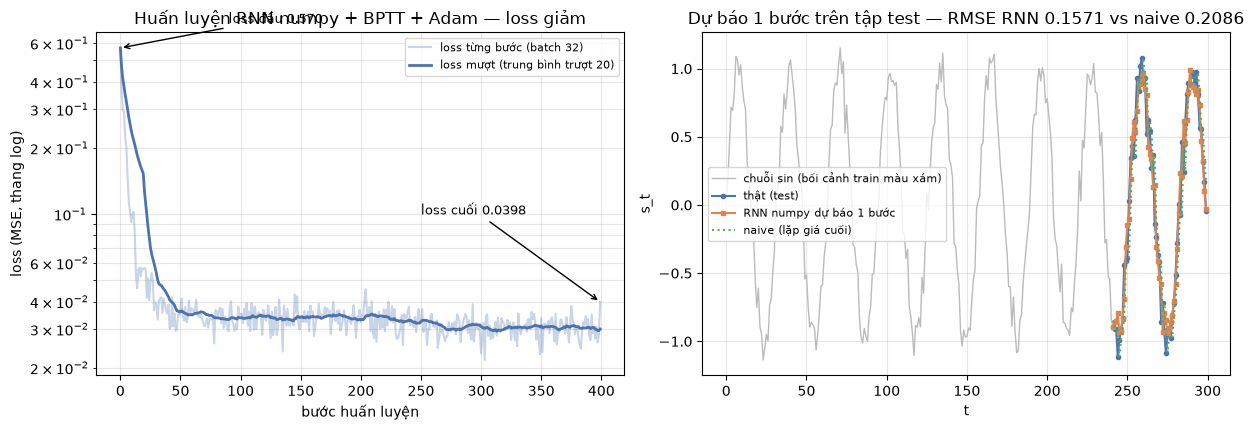

In [23]:
smooth = pd.Series(loss_hist).rolling(20, min_periods=1).mean()
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

ax = axes[0]
ax.plot(loss_hist, alpha=0.30, color="#4C72B0", label="loss từng bước (batch 32)")
ax.plot(smooth, color="#4C72B0", lw=2, label="loss mượt (trung bình trượt 20)")
ax.set_yscale("log")
ax.set_xlabel("bước huấn luyện"); ax.set_ylabel("loss (MSE, thang log)")
ax.set_title("Huấn luyện RNN numpy + BPTT + Adam — loss giảm")
ax.annotate("loss đầu %.3f" % loss_hist[0], xy=(0, loss_hist[0]), xytext=(90, loss_hist[0] * 1.3),
            fontsize=9, arrowprops=dict(arrowstyle="->"))
ax.annotate("loss cuối %.4f" % loss_hist[-1], xy=(399, loss_hist[-1]),
            xytext=(250, loss_hist[-1] * 2.5), fontsize=9,
            arrowprops=dict(arrowstyle="->"))
ax.legend(fontsize=8); ax.grid(alpha=0.3, which="both")

ax = axes[1]
tt = np.arange(n_tr + WIN, 300)                          # trục thời gian của tập test
ax.plot(t11, sine, color="#BBBBBB", lw=1, label="chuỗi sin (bối cảnh train màu xám)")
ax.plot(tt, y_te, "-o", ms=3, color="#4C72B0", label="thật (test)")
ax.plot(tt, pred_test, "-s", ms=3, color="#DD8452", label="RNN numpy dự báo 1 bước")
ax.plot(tt, naive_pred, ":", color="#55A868", label="naive (lặp giá cuối)")
ax.set_xlabel("t"); ax.set_ylabel("s_t")
ax.set_title("Dự báo 1 bước trên tập test — RMSE RNN %.4f vs naive %.4f"
             % (m_rnn["rmse"], m_naive["rmse"]))
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "rnn-05-sine-demo.png", bbox_inches="tight")
plt.show()

 ### Lưu mô hình + meta (quy ước ASM06)

 Lưu `npz` chứa 5 khối tham số và file `rnn_concepts_sine_meta.json` gồm: config
 (window, hidden, epochs, lr, split), metrics test (kèm baseline naive), lịch sử loss.

In [24]:
np.savez(MODEL_DIR / "rnn_concepts_sine.npz", **params_sin)

meta = {
    "model": "vanilla RNN numpy (tự viết, BPTT + Adam + grad clipping)",
    "task": "one-step prediction, sin(0.2t) + 0.1*N(0,1), len 300",
    "config": {"window": WIN, "hidden": HID, "d_x": 1, "d_y": 1,
               "epochs_steps": 400, "batch": 32, "lr": 0.01, "split": 0.8,
               "seed": RANDOM_SEED, "activation": "tanh", "clip_norm": 5.0},
    "metrics_test": m_rnn,
    "baseline_naive": m_naive,
    "loss_first": float(loss_hist[0]),
    "loss_last": float(loss_hist[-1]),
    "loss_history": [float(v) for v in loss_hist],
}
with open(MODEL_DIR / "rnn_concepts_sine_meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

files = sorted(p.name for p in MODEL_DIR.glob("*"))
print("model files:", files)
print("RMSE test: RNN %.4f | naive %.4f | directional acc: RNN %.3f | naive %.3f"
      % (m_rnn["rmse"], m_naive["rmse"], m_rnn["directional_acc"], m_naive["directional_acc"]))

model files: ['rnn_concepts_sine.npz', 'rnn_concepts_sine_meta.json']
RMSE test: RNN 0.1571 | naive 0.2086 | directional acc: RNN 0.559 | naive 0.542


 ---
 ## §12. Bảng tóm tắt: khái niệm ↔ công thức ↔ hàm code

 | Khái niệm | Công thức | Numpy tự viết | PyTorch | Keras |
 |---|---|---|---|---|
 | 1 bước RNN | $h_t = \tanh(W x_t + U h_{t-1} + b_h)$ | `rnn_cell` | `nn.RNN` (nội bộ) | `SimpleRNN` (nội bộ) |
 | Cả chuỗi | $h_0 = 0$; lặp $t = 1..T$; $y_t = V h_t + b_y$ | `rnn_forward` | `rnn_pt(x[None])` | `layer(x[None])` |
 | Kích thước | $W (d_h{\times}d_x)$, $U (d_h{\times}d_h)$, $V (d_y{\times}d_h)$ | — | `weight_ih_l0`, `weight_hh_l0` | `kernel = Wᵀ`, `recurrent = Uᵀ` |
 | Số tham số | $d_h d_x + d_h d_h + d_y d_h + d_h + d_y$ (không phụ thuộc $T$) | `n_params` | `sum(p.numel())` | `layer.count_params()` |
 | Mất mát | $L = \frac{1}{T}\sum_t (y_t - \text{target}_t)^2$ | `loss_seq`, `dloss_seq` | `nn.MSELoss` | `loss="mse"` |
 | BPTT | $\delta_t = (1-h_t^2)\odot(V^\top\delta^y_t + U^\top\delta_{t+1})$ | `rnn_backward` | `loss.backward()` | `fit()` (tự động) |
 | Kiểm tra gradient | sai phân trung tâm, sai số $< 10^{-6}$ | `numeric_grad` | `torch.autograd.gradcheck` | — |
 | Biến mất/bùng nổ | $\|\partial L/\partial h_t\| \sim \|U\|^{T-t}$ | `dh_norms_last_only` | — | — |
 | Cắt gradient | $g \leftarrow g\min(1, c/\|g\|)$ | `clip_grad_norm` | `clip_grad_norm_` | `clipvalue/clipnorm` |
 | Tối ưu | Adam $\hat m/(\sqrt{\hat v}+\epsilon)$ | `SimpleAdam` | `torch.optim.Adam` | `keras.optimizers.Adam` |
 | Đánh giá | RMSE, MAE, MAPE, $R^2$, directional acc | `regression_metrics` | tự viết / sklearn | tự viết / sklearn |

 ### Checklist "đã hiểu RNN"

 1. Giải thích được vì sao MLP mất thứ tự, CNN khó nhớ dài hạn (§1).
 2. Vẽ được sơ đồ cuộn/trải và nói rõ $h_t$ là bộ nhớ (§2).
 3. Nêu đúng **kích thước** và vai trò W (input), U (ký ức), V (đọc ra) (§3).
 4. Tính tay được vài bước $h_t = \tanh(W x_t + U h_{t-1} + b_h)$ (§5).
 5. Viết được `rnn_forward` + `rnn_backward`, gradient check đạt $< 10^{-6}$ (§4, §7).
 6. Giải thích được vì sao $\|U\| < 1$ làm gradient biến mất và cách chữa (§8).
 7. Map được trọng số numpy ↔ `nn.RNN` ↔ `SimpleRNN` và kiểm chứng bằng copy weights (§9, §10).
 8. Huấn luyện thành công RNN tự viết trên chuỗi sin, so với naive baseline (§11).